In [3]:
import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Path to the results directory, relative to the project root.
# Adjust if you run the notebook from elsewhere.
RESULTS_DIR = Path("results")

# Regex patterns to pull times out of summary.txt.
PYSPY_RE = re.compile(r"py-spy time:\s*([\d.]+)s")
MEMRAY_RE = re.compile(r"memray time:\s*([\d.]+)s")

In [4]:
def parse_summary(summary_path):
    """Return (pyspy_time, memray_time) from a summary.txt, or (None, None) on failure."""
    text = summary_path.read_text()
    pyspy = PYSPY_RE.search(text)
    memray = MEMRAY_RE.search(text)
    return (
        float(pyspy.group(1)) if pyspy else None,
        float(memray.group(1)) if memray else None,
    )


def latest_run(config_dir):
    """Return the latest timestamped subdirectory inside a config folder."""
    runs = sorted([d for d in config_dir.iterdir() if d.is_dir()])
    return runs[-1] if runs else None


def collect_results(results_dir):
    """Walk results_dir, pick the latest run per config, return a DataFrame."""
    rows = []
    for config_dir in sorted(results_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        run_dir = latest_run(config_dir)
        if run_dir is None:
            continue
        summary = run_dir / "summary.txt"
        if not summary.exists():
            print(f"[skip] no summary.txt in {run_dir}")
            continue
        pyspy_time, memray_time = parse_summary(summary)
        rows.append({
            "config": config_dir.name,
            "pyspy_time": pyspy_time,
            "memray_time": memray_time,
            "run": run_dir.name,
        })
    return pd.DataFrame(rows)


df = collect_results(RESULTS_DIR)
df = df.sort_values("config").reset_index(drop=True)

In [5]:
def parse_summary(summary_path):
    """Return (pyspy_time, memray_time) from a summary.txt, or (None, None) on failure."""
    text = summary_path.read_text()
    pyspy = PYSPY_RE.search(text)
    memray = MEMRAY_RE.search(text)
    return (
        float(pyspy.group(1)) if pyspy else None,
        float(memray.group(1)) if memray else None,
    )


def latest_run(config_dir):
    """Return the latest timestamped subdirectory inside a config folder."""
    runs = sorted([d for d in config_dir.iterdir() if d.is_dir()])
    return runs[-1] if runs else None


def collect_results(results_dir):
    """Walk results_dir, pick the latest run per config, return a DataFrame."""
    rows = []
    for config_dir in sorted(results_dir.iterdir()):
        if not config_dir.is_dir():
            continue
        run_dir = latest_run(config_dir)
        if run_dir is None:
            continue
        summary = run_dir / "summary.txt"
        if not summary.exists():
            print(f"[skip] no summary.txt in {run_dir}")
            continue
        pyspy_time, memray_time = parse_summary(summary)
        rows.append({
            "config": config_dir.name,
            "pyspy_time": pyspy_time,
            "memray_time": memray_time,
            "run": run_dir.name,
        })
    return pd.DataFrame(rows)


df = collect_results(RESULTS_DIR)
df = df.sort_values("config").reset_index(drop=True)

In [6]:
df

,config,pyspy_time,memray_time,run
0,backends_config_fedavg_tensorflow,41.06,66.40,2026-04-20_16-34-16
1,backends_config_fedavg_torch,30.79,34.74,2026-04-20_16-36-04
2,regularizers_config_fedavg_torch_fedprox,42.12,48.74,2026-04-20_16-39-32
3,regularizers_config_fedavg_torch_lasso,37.87,35.24,2026-04-20_16-37-09
4,regularizers_config_fedavg_torch_ridge,34.10,35.63,2026-04-20_16-38-22
5,scaffold_config_fedavg_torch_scaffold,32.04,35.31,2026-04-20_16-41-03


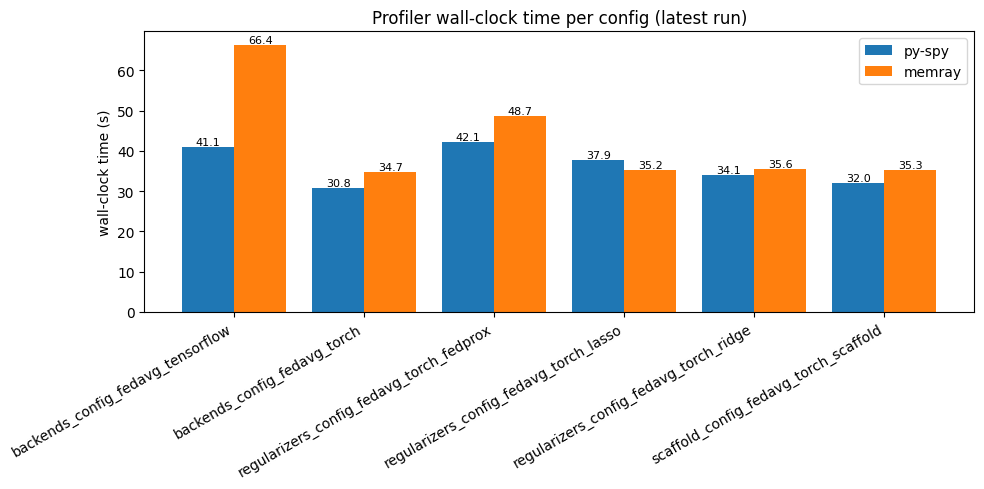

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(df))
width = 0.4

ax.bar([i - width/2 for i in x], df["pyspy_time"], width, label="py-spy")
ax.bar([i + width/2 for i in x], df["memray_time"], width, label="memray")

ax.set_xticks(list(x))
ax.set_xticklabels(df["config"], rotation=30, ha="right")
ax.set_ylabel("wall-clock time (s)")
ax.set_title("Profiler wall-clock time per config (latest run)")
ax.legend()

# Annotate bars with their values
for i, (p, m) in enumerate(zip(df["pyspy_time"], df["memray_time"])):
    if p is not None:
        ax.text(i - width/2, p, f"{p:.1f}", ha="center", va="bottom", fontsize=8)
    if m is not None:
        ax.text(i + width/2, m, f"{m:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()